# ❤️ Heart Disease Prediction using Decision Tree & Random Forest
This notebook implements Decision Tree and Random Forest classifiers on the heart disease dataset.

## Step 1: Import Libraries

In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    

## Step 2: Load Dataset

In [20]:

df = pd.read_csv("heart.csv")
print(df.to_string())
    

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
0      52    1   0       125   212    0        1      168      0      1.0      2   2     3       0
1      53    1   0       140   203    1        0      155      1      3.1      0   0     3       0
2      70    1   0       145   174    0        1      125      1      2.6      0   0     3       0
3      61    1   0       148   203    0        1      161      0      0.0      2   1     3       0
4      62    0   0       138   294    1        1      106      0      1.9      1   3     2       0
5      58    0   0       100   248    0        0      122      0      1.0      1   0     2       1
6      58    1   0       114   318    0        2      140      0      4.4      0   3     1       0
7      55    1   0       160   289    0        0      145      1      0.8      1   1     3       0
8      46    1   0       120   249    0        0      144      0      0.8      2   0     3       0
9      54 

## Step 3: Preprocess Dataset

In [21]:

# Check for nulls
print("Null values in dataset:")
print(df.isnull().sum())

# Define features and target
X = df.drop('target', axis=1)
y = df['target']
    

Null values in dataset:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Step 4: Train-Test Split

In [22]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    

## Step 5: Decision Tree Classifier

In [23]:

dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)
y_pred_tree = dtree.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))
    

Decision Tree Accuracy: 0.8
[[71 31]
 [10 93]]
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



## Step 6: Visualize the Decision Tree

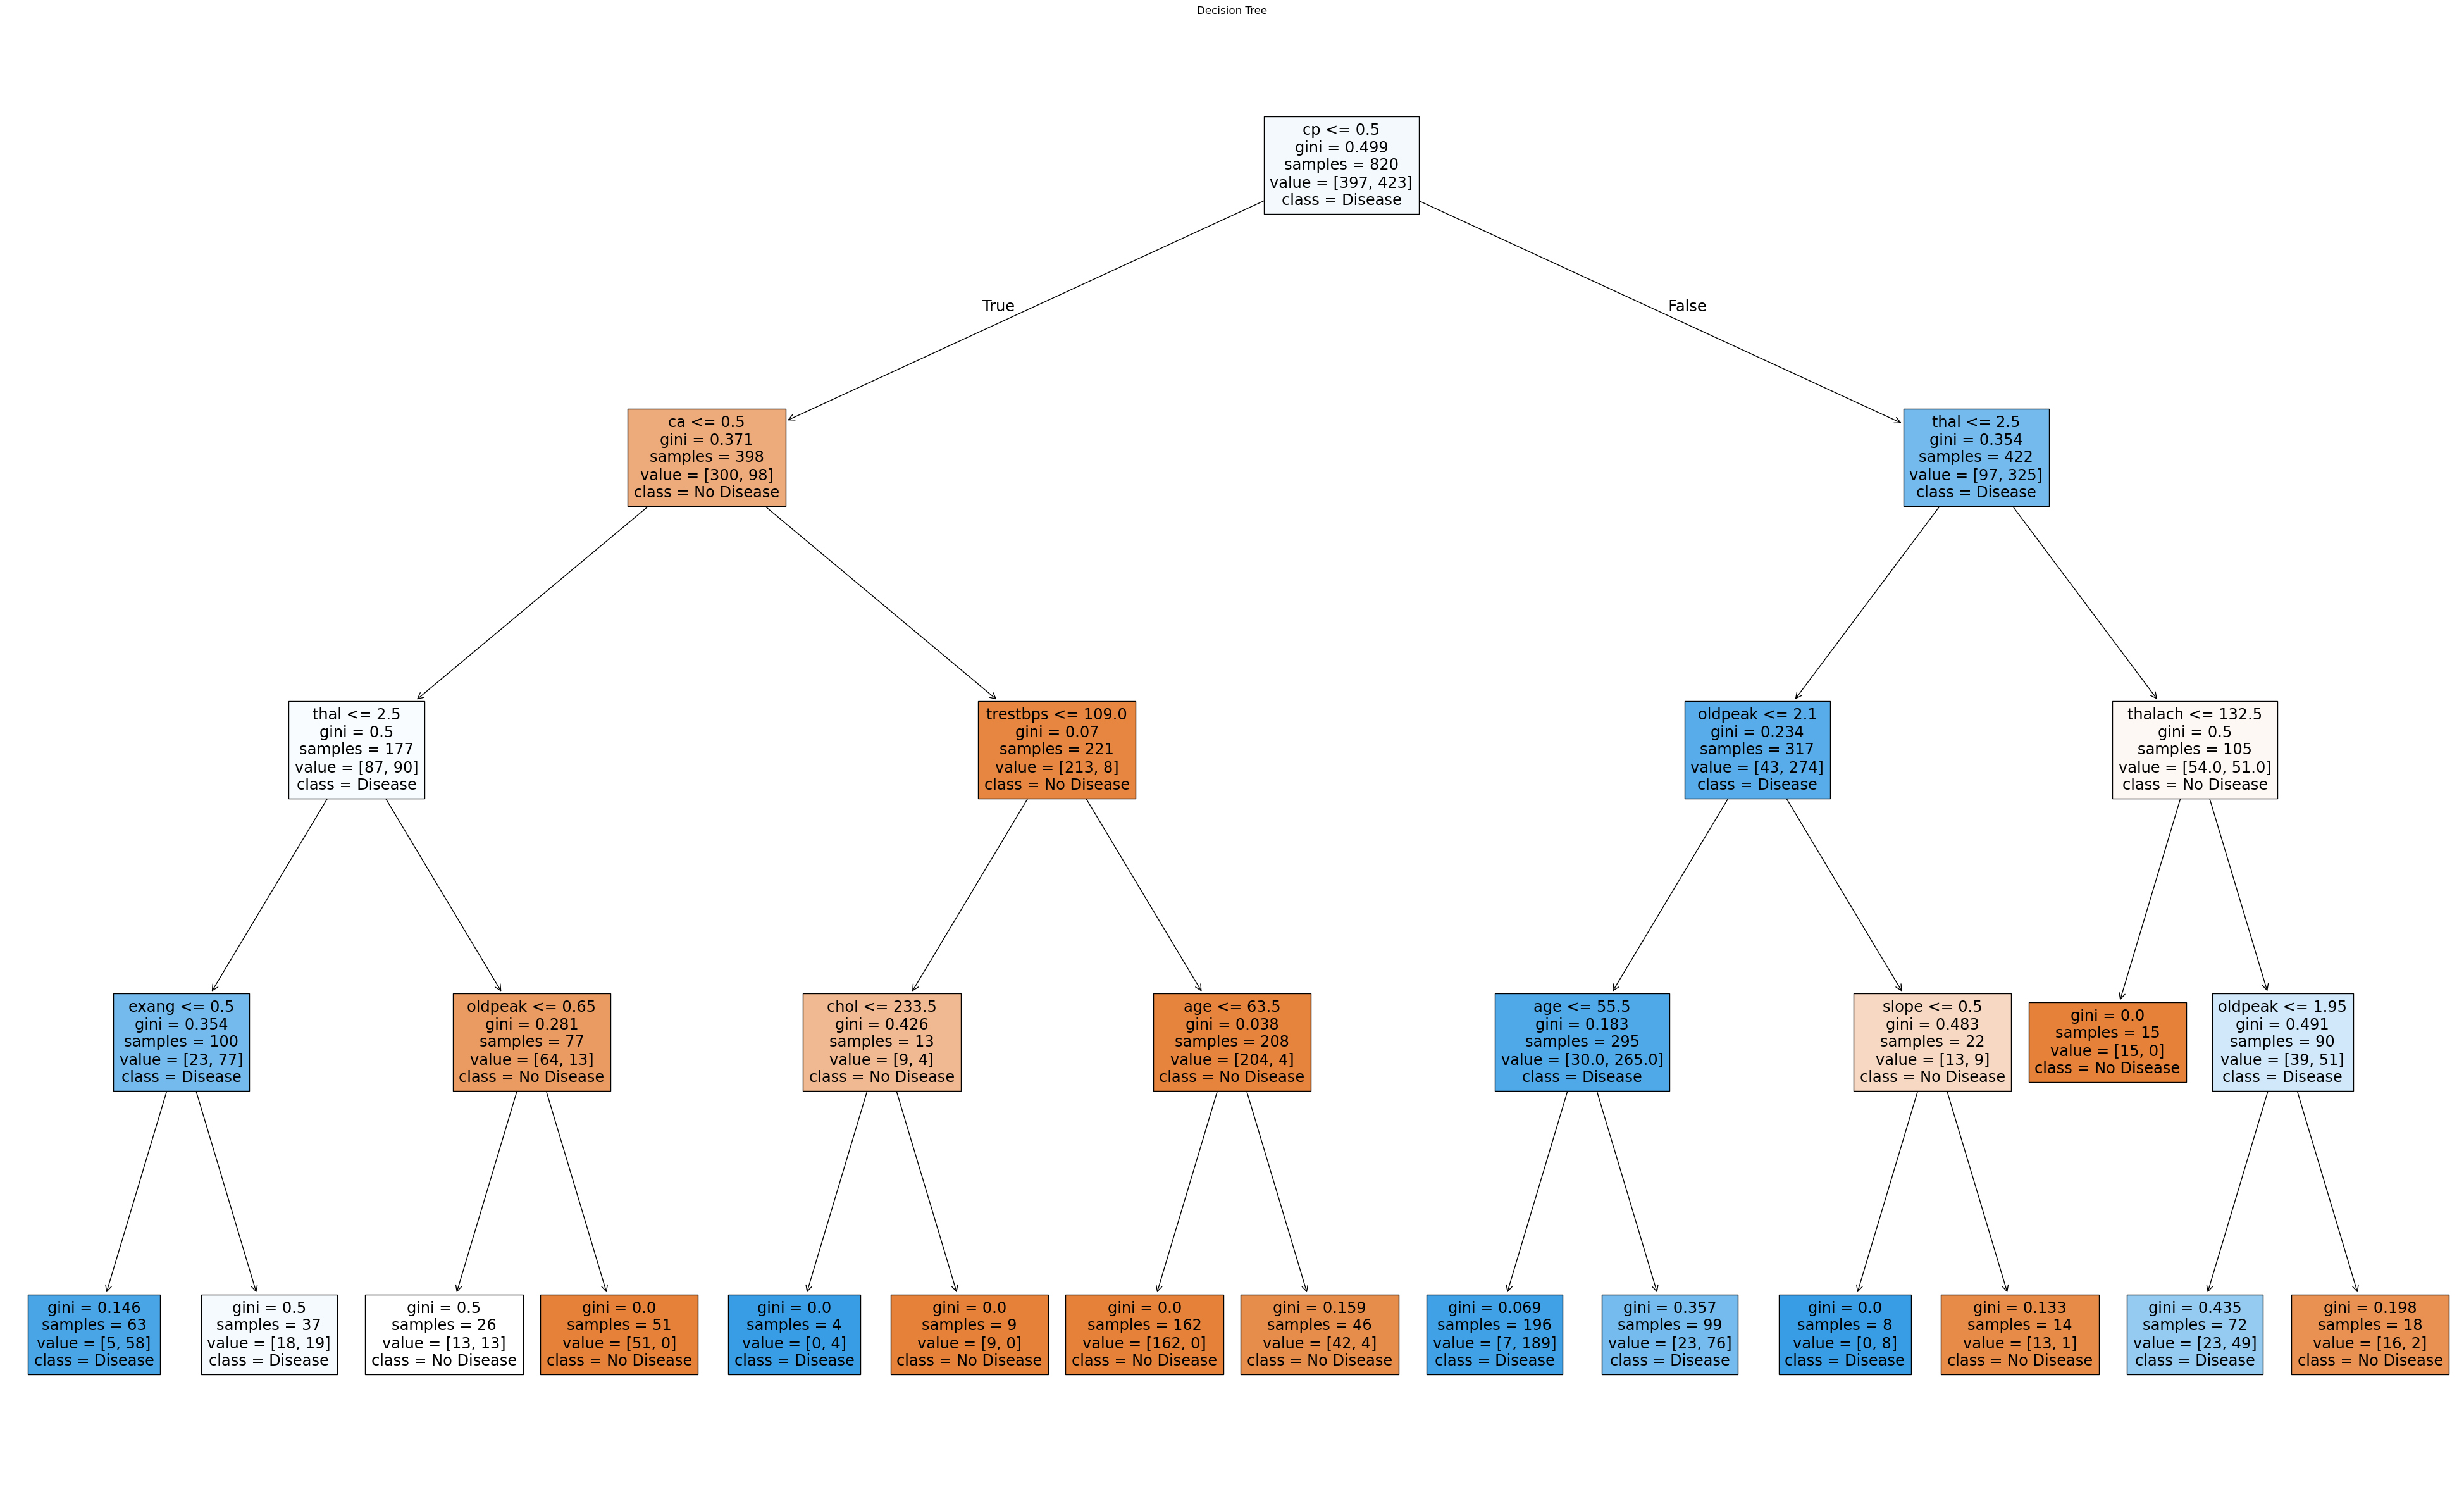

In [ ]:

plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True)
plt.title("Decision Tree")
plt.show()
    

## Step 7: Random Forest Classifier

In [25]:

rforest = RandomForestClassifier(n_estimators=100, random_state=42)
rforest.fit(X_train, y_train)
y_pred_rf = rforest.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
    

Random Forest Accuracy: 0.9853658536585366
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



## Step 8: Feature Importances (Random Forest)

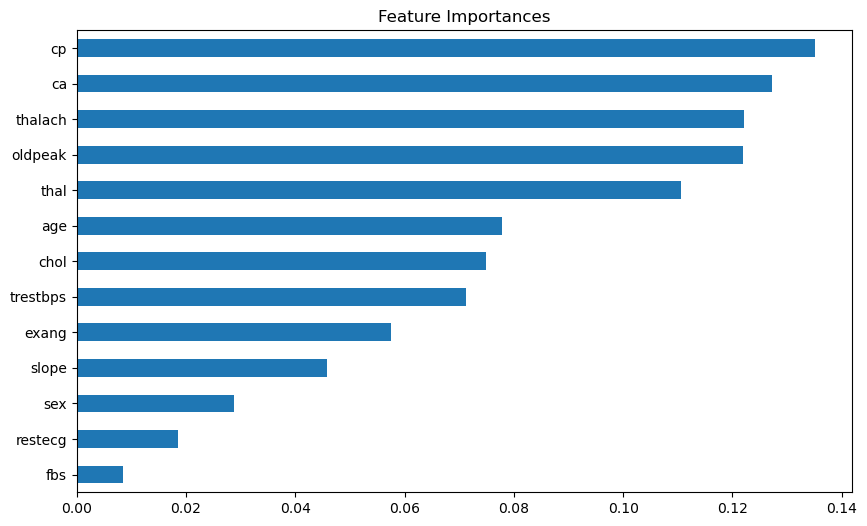

In [26]:

importances = pd.Series(rforest.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10,6), title='Feature Importances')
plt.show()
    

## Step 9: Cross-Validation Scores

In [27]:

tree_scores = cross_val_score(dtree, X, y, cv=5)
rf_scores = cross_val_score(rforest, X, y, cv=5)

print(f"Decision Tree CV Accuracy: {tree_scores.mean():.3f}")
print(f"Random Forest CV Accuracy: {rf_scores.mean():.3f}")
    

Decision Tree CV Accuracy: 0.834
Random Forest CV Accuracy: 0.997
